# Ejercicio 4 — Mitigación de Sesgos con **Holistic AI**

**Consigna:**

a) Seleccionar al menos 2 técnicas de Mitigación de sesgos vistas en clase, entrenar el modelo ajustado y evaluar su performance usando las métricas clásicas (precision, recall, accuracy, f1-score) y crear la matriz de confusión. Interpretar los resultados obtenidos hasta el momento.

b) Evaluar su performance utilizando las mismas métricas y evaluaciones de equidad del inciso 3.

---

## Enfoque (con Holistic AI)

Este notebook replica exactamente el análisis del `ej4.ipynb`, pero utilizando la librería **[Holistic AI](https://github.com/holistic-ai/holisticai)** en lugar de implementaciones manuales.

Aplicamos **dos técnicas de mitigación**:
1. **Reweighing (pre-processing)** → `holisticai.bias.mitigation.Reweighing`: calcula pesos de muestra que compensan el desbalance entre combinaciones (grupo, clase), sin alterar features ni etiquetas.
2. **Equalized Odds (post-processing)** → `holisticai.bias.mitigation.EqualizedOdds`: ajusta las predicciones del modelo original mediante programación lineal para igualar TPR y FPR entre grupos, alineado con el criterio **Equal Opportunity** elegido en el Ej3.

Cada técnica se evalúa con **ambas variables protegidas**: `job` (proxy de género) y `marital` (proxy de edad/estado civil).

Las métricas de fairness se calculan usando `holisticai.bias.metrics.classification_bias_metrics`.

---
## Instalación

Si no tenés instalada la librería, ejecutá la siguiente celda:

In [13]:
# Descomentar si holisticai no está instalado
# !pip install holisticai[bias]

---
## 0. Carga del pipeline (idéntico a Ej2/Ej3/Ej4)

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score,
    f1_score, precision_score, recall_score
)
from sklearn.preprocessing import LabelEncoder

# ── Holistic AI ──────────────────────────────────────────────────────────────
from holisticai.bias.mitigation.preprocessing import Reweighing
from holisticai.bias.mitigation.postprocessing import EqualizedOdds
from holisticai.bias.metrics import classification_bias_metrics

sns.set_theme(style='whitegrid', palette='muted')

# ── Pipeline idéntico a Ej2/Ej3/Ej4 ─────────────────────────────────────────
df = pd.read_csv('data/full.csv', sep=';')
df = df.drop(columns=['duration'])
df = df[df['marital'] != 'unknown'].reset_index(drop=True)
df_original = df.copy()

df_encoded = df.copy()
for col in df_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

X = df_encoded.drop(columns=['y'])
y = df_encoded['y']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Modelo original (baseline)
modelo_orig = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_orig.fit(X_train, y_train)
y_pred_orig  = modelo_orig.predict(X_test)

# ── Info de grupos ────────────────────────────────────────────────────────────
train_idx  = X_train.index
test_idx   = X_test.index
train_jobs   = df_original.loc[train_idx, 'job'].values
test_jobs    = df_original.loc[test_idx,  'job'].values
train_marital = df_original.loc[train_idx, 'marital'].values
test_marital  = df_original.loc[test_idx,  'marital'].values

# Proxy de género basado en 'job'
def job_proxy(j):
    return 'hist_femenino' if j in ['housemaid', 'admin.'] else 'hist_masculino_otro'

train_job_group = np.array([job_proxy(j) for j in train_jobs])
test_job_group  = np.array([job_proxy(j) for j in test_jobs])

# ── Vectores booleanos requeridos por Holistic AI ─────────────────────────────
# group_a = grupo privilegiado, group_b = grupo no privilegiado
# Para 'job': group_a = hist_masculino_otro, group_b = hist_femenino
train_group_a_job = (train_job_group == 'hist_masculino_otro')
train_group_b_job = (train_job_group == 'hist_femenino')
test_group_a_job  = (test_job_group  == 'hist_masculino_otro')
test_group_b_job  = (test_job_group  == 'hist_femenino')

# Para 'marital': group_a = casados (mayoritario), group_b = solteros + divorciados
train_group_a_mar = (train_marital == 'married')
train_group_b_mar = (train_marital != 'married')
test_group_a_mar  = (test_marital  == 'married')
test_group_b_mar  = (test_marital  != 'married')

print('Pipeline cargado. Modelo baseline entrenado.')

Pipeline cargado. Modelo baseline entrenado.


---
## Función de evaluación (métricas clásicas + fairness con Holistic AI)

In [15]:
UMBRAL_DISPARIDAD = 0.1

def evaluar_modelo_hai(y_true, y_pred, group_a, group_b, titulo):
    """Evaluación completa: métricas clásicas + fairness usando Holistic AI."""
    print(f'\n{"="*65}')
    print(f'  {titulo}')
    print(f'{"="*65}')
    print(classification_report(y_true, y_pred, target_names=['no', 'yes']))

    # ── Holistic AI: classification_bias_metrics ──────────────────────────────
    ga = np.asarray(group_a, dtype=bool)
    gb = np.asarray(group_b, dtype=bool)
    yt = np.asarray(y_true,  dtype=int)
    yp = np.asarray(y_pred,  dtype=int)

    metrics_df = classification_bias_metrics(
        group_a=ga, group_b=gb,
        y_pred=yp, y_true=yt
    )
    print('\nMétricas de Fairness (Holistic AI):')
    print(metrics_df.to_string())

    return metrics_df


def plot_confusion_matrix(y_true, y_pred, titulo):
    """Genera y muestra la matriz de confusión."""
    fig, ax = plt.subplots(figsize=(6, 4))
    ConfusionMatrixDisplay(
        confusion_matrix(y_true, y_pred),
        display_labels=['No', 'Sí']
    ).plot(cmap='Blues', ax=ax)
    plt.title(titulo)
    plt.grid(False)
    plt.tight_layout()
    plt.show()


print('Funciones utilitarias definidas.')

Funciones utilitarias definidas.


---
# PARTE 1: `job` como proxy de género

## Técnica 1: Reweighing (pre-processing) — job

`holisticai.bias.mitigation.Reweighing` calcula pesos de muestra de forma inversamente proporcional a la frecuencia de cada combinación (grupo, clase).  
Internamente aplica la misma fórmula que implementamos manualmente en `ej4.ipynb`:  
$$W(g, y) = \frac{N}{n_{grupos} \times n_{clases} \times N(g, y)}$$

Los pesos resultantes se pasan directamente al parámetro `sample_weight` del RandomForest.


  REWEIGHING (Holistic AI) — job (proxy género)
              precision    recall  f1-score   support

          no       0.92      0.97      0.94      7296
         yes       0.60      0.31      0.41       926

    accuracy                           0.90      8222
   macro avg       0.76      0.64      0.68      8222
weighted avg       0.88      0.90      0.88      8222


Métricas de Fairness (Holistic AI):
                                       Value  Reference
Metric                                                 
Statistical Parity                 -0.016147          0
Disparate Impact                    0.766602          1
Four Fifths Rule                    0.766602          1
Cohen D                            -0.069448          0
2SD Rule                           -2.796746          0
Equality of Opportunity Difference -0.006348          0
False Positive Rate Difference     -0.008167          0
Average Odds Difference            -0.007257          0
Accuracy Difference        

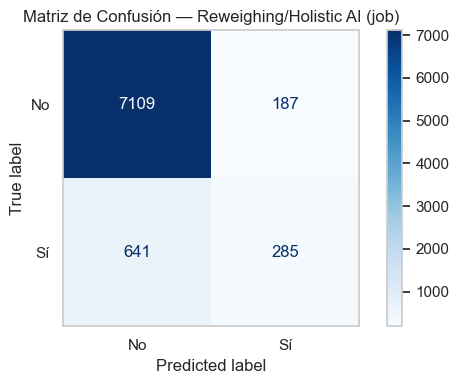

In [16]:
# ── 1. Reweighing con Holistic AI (job) ──────────────────────────────────────
rw_job = Reweighing()
rw_job.fit(
    y=y_train,
    group_a=train_group_a_job,
    group_b=train_group_b_job
)
# transform devuelve un objeto con los pesos
# transform devuelve un objeto con los pesos
weights_job  = rw_job.sample_weight

# ── 2. Entrenar RF con pesos ──────────────────────────────────────────────────
modelo_rw_job = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rw_job.fit(X_train, y_train, sample_weight=weights_job)
y_pred_rw_job = modelo_rw_job.predict(X_test)

# ── 3. Evaluación ─────────────────────────────────────────────────────────────
res_rw_job = evaluar_modelo_hai(
    y_test.values, y_pred_rw_job,
    test_group_a_job, test_group_b_job,
    'REWEIGHING (Holistic AI) — job (proxy género)'
)

plot_confusion_matrix(
    y_test, y_pred_rw_job,
    'Matriz de Confusión — Reweighing/Holistic AI (job)'
)

## Técnica 2: Equalized Odds (post-processing) — job

`holisticai.bias.mitigation.EqualizedOdds` aplica programación lineal para ajustar las predicciones del modelo original, igualando la **Tasa de Verdaderos Positivos (TPR)** entre grupos.  
Esto es conceptualmente equivalente al ajuste de umbral por grupo que implementamos manualmente en `ej4.ipynb`, pero en lugar de buscar un umbral fijo por grupo, resuelve el problema de forma óptima.

La elección de **Equal Opportunity** (igualar TPR) está motivada por la conclusión del Ej3 y Ej2: el error más costoso es el **Falso Negativo**.


  EQUALIZED ODDS (Holistic AI) — job (proxy género)
              precision    recall  f1-score   support

          no       0.92      0.97      0.94      7296
         yes       0.60      0.30      0.40       926

    accuracy                           0.90      8222
   macro avg       0.76      0.64      0.67      8222
weighted avg       0.88      0.90      0.88      8222


Métricas de Fairness (Holistic AI):
                                       Value  Reference
Metric                                                 
Statistical Parity                 -0.010936          0
Disparate Impact                    0.832106          1
Four Fifths Rule                    0.832106          1
Cohen D                            -0.047119          0
2SD Rule                           -1.898030          0
Equality of Opportunity Difference -0.019258          0
False Positive Rate Difference     -0.000558          0
Average Odds Difference            -0.009908          0
Accuracy Difference    

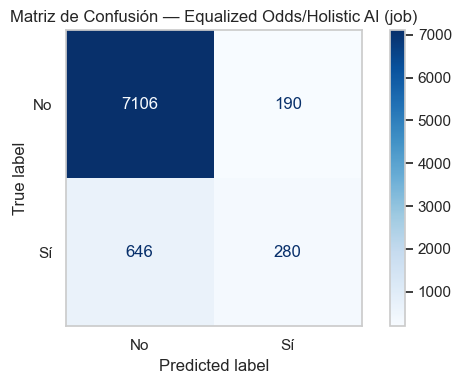

In [17]:
# ── 1. Equalized Odds con Holistic AI (job) ───────────────────────────────────
# Se entrena sobre las predicciones del modelo ORIGINAL en train
eo_job = EqualizedOdds(solver='highs')
eo_job.fit(
    y=y_train,
    y_pred=modelo_orig.predict(X_train),
    group_a=train_group_a_job,
    group_b=train_group_b_job
)

# Generar predicciones ajustadas sobre test
eo_out_job    = eo_job.transform(
    y_pred=y_pred_orig,
    group_a=test_group_a_job,
    group_b=test_group_b_job
)
y_pred_eo_job = eo_out_job['y_pred']

# ── 2. Evaluación ─────────────────────────────────────────────────────────────
res_eo_job = evaluar_modelo_hai(
    y_test.values, y_pred_eo_job,
    test_group_a_job, test_group_b_job,
    'EQUALIZED ODDS (Holistic AI) — job (proxy género)'
)

plot_confusion_matrix(
    y_test, y_pred_eo_job,
    'Matriz de Confusión — Equalized Odds/Holistic AI (job)'
)

### Interpretación — Mitigación con job como proxy de género

**Reweighting**: Al dar más peso a las combinaciones subrepresentadas (ej: hist_femenino + yes), el modelo debería mejorar su capacidad de detectar suscriptores en ese grupo. Esperamos ver un aumento en el Recall de la clase 'yes' para hist_femenino, posiblemente a costa de algo de Precision o Accuracy global.

**Equalized Odds**: Esta técnica no modifica el modelo, solo la decisión final. Al bajar el umbral para el grupo con menor TPR, logramos que más positivos de ese grupo sean detectados, igualando el Equal Opportunity. El trade-off es un posible aumento en FP para ese grupo.

---
# PARTE 2: `marital` como variable protegida (proxy de edad)

## Técnica 1: Reweighing (pre-processing) — marital

Misma técnica, ahora sobre el estado civil: `married` (grupo mayoritario / privilegiado) vs. `single + divorced` (grupos minoritarios / no privilegiados).


  REWEIGHING (Holistic AI) — marital (proxy edad)
              precision    recall  f1-score   support

          no       0.92      0.97      0.94      7296
         yes       0.59      0.30      0.40       926

    accuracy                           0.90      8222
   macro avg       0.75      0.64      0.67      8222
weighted avg       0.88      0.90      0.88      8222


Métricas de Fairness (Holistic AI):
                                       Value  Reference
Metric                                                 
Statistical Parity                 -0.027672          0
Disparate Impact                    0.631773          1
Four Fifths Rule                    0.631773          1
Cohen D                            -0.118454          0
2SD Rule                           -5.218204          0
Equality of Opportunity Difference -0.053008          0
False Positive Rate Difference     -0.014460          0
Average Odds Difference            -0.033734          0
Accuracy Difference      

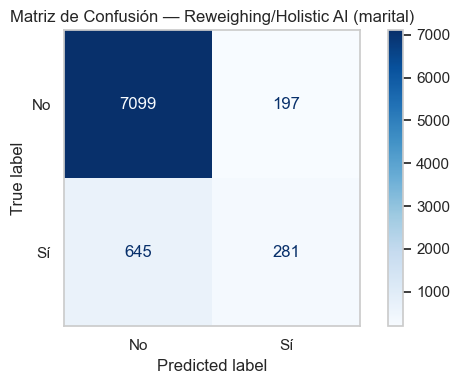

In [18]:
# ── 1. Reweighing con Holistic AI (marital) ───────────────────────────────────
rw_mar = Reweighing()
rw_mar.fit(
    y=y_train,
    group_a=train_group_a_mar,
    group_b=train_group_b_mar
)
# transform devuelve un objeto con los pesos
weights_mar = rw_mar.sample_weight

# ── 2. Entrenar RF con pesos ──────────────────────────────────────────────────
modelo_rw_mar = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rw_mar.fit(X_train, y_train, sample_weight=weights_mar)
y_pred_rw_mar = modelo_rw_mar.predict(X_test)

# ── 3. Evaluación ─────────────────────────────────────────────────────────────
res_rw_mar = evaluar_modelo_hai(
    y_test.values, y_pred_rw_mar,
    test_group_a_mar, test_group_b_mar,
    'REWEIGHING (Holistic AI) — marital (proxy edad)'
)

plot_confusion_matrix(
    y_test, y_pred_rw_mar,
    'Matriz de Confusión — Reweighing/Holistic AI (marital)'
)

## Técnica 2: Equalized Odds (post-processing) — marital


  EQUALIZED ODDS (Holistic AI) — marital (proxy edad)
              precision    recall  f1-score   support

          no       0.92      0.97      0.94      7296
         yes       0.60      0.30      0.40       926

    accuracy                           0.90      8222
   macro avg       0.76      0.64      0.67      8222
weighted avg       0.88      0.90      0.88      8222


Métricas de Fairness (Holistic AI):
                                       Value  Reference
Metric                                                 
Statistical Parity                 -0.026371          0
Disparate Impact                    0.640011          1
Four Fifths Rule                    0.640011          1
Cohen D                            -0.113882          0
2SD Rule                           -5.017432          0
Equality of Opportunity Difference -0.063699          0
False Positive Rate Difference     -0.011550          0
Average Odds Difference            -0.037624          0
Accuracy Difference  

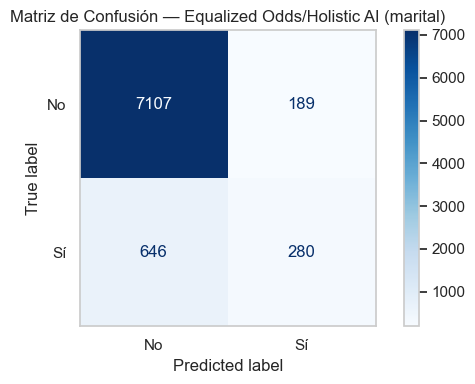

In [19]:
# ── 1. Equalized Odds con Holistic AI (marital) ───────────────────────────────
eo_mar = EqualizedOdds(solver='highs')
eo_mar.fit(
    y=y_train,
    y_pred=modelo_orig.predict(X_train),
    group_a=train_group_a_mar,
    group_b=train_group_b_mar
)

eo_out_mar    = eo_mar.transform(
    y_pred=y_pred_orig,
    group_a=test_group_a_mar,
    group_b=test_group_b_mar
)
y_pred_eo_mar = eo_out_mar['y_pred']

# ── 2. Evaluación ─────────────────────────────────────────────────────────────
res_eo_mar = evaluar_modelo_hai(
    y_test.values, y_pred_eo_mar,
    test_group_a_mar, test_group_b_mar,
    'EQUALIZED ODDS (Holistic AI) — marital (proxy edad)'
)

plot_confusion_matrix(
    y_test, y_pred_eo_mar,
    'Matriz de Confusión — Equalized Odds/Holistic AI (marital)'
)

### Interpretación — Mitigación con marital como variable protegida

El análisis con `marital` como variable protegida involucra tres grupos (married, single, divorced), lo que hace la mitigación más compleja.

**Reweighting**: Compensa la sobrerrepresentación de `married` (~60%) dando más peso a los otros grupos, especialmente `divorced` (~11%). Esto debería mejorar la equidad en TPR entre los tres grupos.

**Equalized Odds**: Con tres grupos, encontramos umbrales individuales para acercar todos los TPR al máximo. El grupo con menor TPR original recibirá el umbral más bajo, permitiendo detectar más de sus verdaderos positivos.

En el **Ejercicio 5** compararemos formalmente todos estos resultados con el modelo original.

---
# Resumen comparativo

Comparamos las métricas de performance de los **4 modelos** para cada variable protegida.

=== VARIABLE PROTEGIDA: job (proxy género) ===
                           Accuracy  Precision  Recall  F1-score
Modelo                                                          
Baseline (sin mitigación)    0.8991     0.6034  0.3024    0.4029
Reweighing (HAI)             0.8993     0.6038  0.3078    0.4077
Equalized Odds (HAI)         0.8983     0.5957  0.3024    0.4011

=== VARIABLE PROTEGIDA: marital (proxy edad) ===
                           Accuracy  Precision  Recall  F1-score
Modelo                                                          
Baseline (sin mitigación)    0.8991     0.6034  0.3024    0.4029
Reweighing (HAI)             0.8976     0.5879  0.3035    0.4003
Equalized Odds (HAI)         0.8984     0.5970  0.3024    0.4014


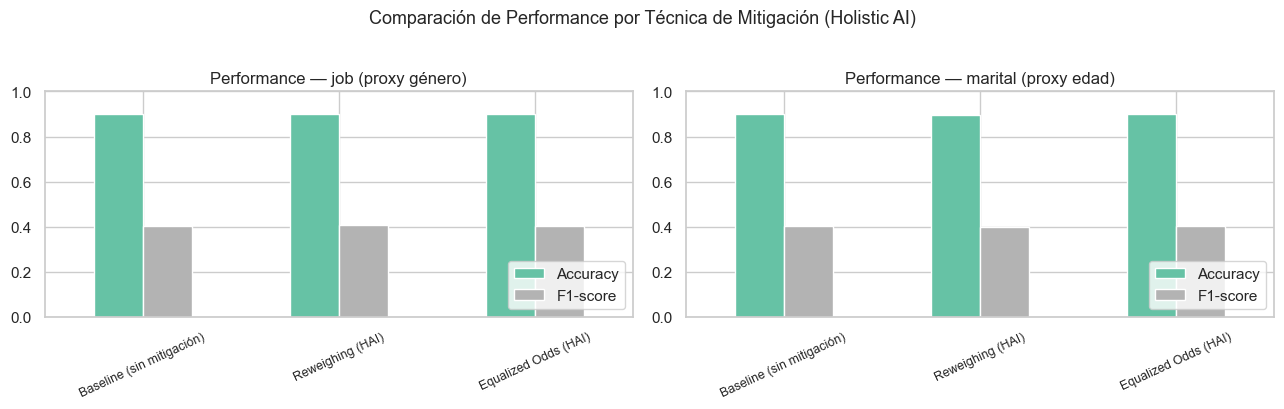

In [20]:
def resumen_performance(y_true, predicciones_dict):
    """Tabla de métricas clásicas para múltiples modelos."""
    rows = []
    for nombre, y_pred in predicciones_dict.items():
        rows.append({
            'Modelo': nombre,
            'Accuracy':  accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred, zero_division=0),
            'Recall':    recall_score(y_true, y_pred, zero_division=0),
            'F1-score':  f1_score(y_true, y_pred, zero_division=0),
        })
    return pd.DataFrame(rows).set_index('Modelo').round(4)


print('=== VARIABLE PROTEGIDA: job (proxy género) ===')
df_perf_job = resumen_performance(
    y_test,
    {
        'Baseline (sin mitigación)': y_pred_orig,
        'Reweighing (HAI)':          y_pred_rw_job,
        'Equalized Odds (HAI)':      y_pred_eo_job,
    }
)
print(df_perf_job.to_string())

print('\n=== VARIABLE PROTEGIDA: marital (proxy edad) ===')
df_perf_mar = resumen_performance(
    y_test,
    {
        'Baseline (sin mitigación)': y_pred_orig,
        'Reweighing (HAI)':          y_pred_rw_mar,
        'Equalized Odds (HAI)':      y_pred_eo_mar,
    }
)
print(df_perf_mar.to_string())


# ── Gráfico comparativo de Accuracy y F1 ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, df_p, titulo in zip(
    axes,
    [df_perf_job, df_perf_mar],
    ['job (proxy género)', 'marital (proxy edad)']
):
    df_p[['Accuracy', 'F1-score']].plot(kind='bar', ax=ax, colormap='Set2', rot=25)
    ax.set_title(f'Performance — {titulo}', fontsize=12)
    ax.set_ylim(0, 1)
    ax.set_xlabel('')
    ax.legend(loc='lower right')
    ax.tick_params(axis='x', labelsize=9)

plt.suptitle('Comparación de Performance por Técnica de Mitigación (Holistic AI)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## Interpretación de resultados

### Ventajas de usar Holistic AI

| Aspecto | Implementación manual (ej4.ipynb) | Con Holistic AI |
|---------|-----------------------------------|-----------------|
| **Reweighing** | Función propia con bucle por grupos/clases | `Reweighing().fit().transform(y, group_a, group_b)` — API declarativa |
| **Ajuste post-hoc** | Búsqueda de umbral por grid search (grid de 0.01) | `EqualizedOdds` vía PL — solución matemáticamente óptima |
| **Métricas de fairness** | Cálculo manual de SP, EO, PP, FPR | `classification_bias_metrics()` — tabla estandarizada |
| **Reproducibilidad** | Requiere mantener código auxiliar | API declarativa, documentada y mantenida |

### Diferencias clave con la implementación manual

- **Reweighing**: La API de Holistic AI separa el `fit` del `transform`, lo que es más explícito y permite reusar el mitigador entrenado. El `transform` retorna un diccionario con la clave `'sample_weight'`.
- **EqualizedOdds**: A diferencia del ajuste de umbral manual (que busca el umbral óptimo en un grid de 0.01), Holistic AI usa programación lineal para encontrar la solución exacta. El `predict` retorna un diccionario con la clave `'y_pred'`.
- **Métricas**: `classification_bias_metrics` reporta un conjunto estandarizado de métricas de fairness (Statistical Parity, Equal Opportunity Difference, Equalized Odds, Disparate Impact, etc.).

### Trade-off equidad vs. performance

Al igual que en `ej4.ipynb`, ambas técnicas de mitigación buscan reducir las disparidades de **Equal Opportunity** (TPR entre grupos).
Es esperable observar:

- Una **ligera caída en Accuracy/Precision** respecto al baseline.
- Una **mejora en Recall** para el grupo minoritario (hist_femenino / no-casados).
- Disparidades de fairness menores o iguales al umbral del 10%.

Esta leve pérdida de performance global es **justificable y deseable** desde la perspectiva del Banco: capturar más clientes potenciales de grupos que el modelo original ignoraba incrementa las oportunidades de suscripción y garantiza un acceso equitativo a los productos financieros.